# Underfitting Model

by Niklas Vogel and Kevin Stupar

## Setup
This notebook creates an underfitting model and evaluates it.

Before executing this please make sure you did download and extract the data using an unzip tool optimized for your OS (`unzip` in WSL could take a long time)
The Download can be done using `setup.sh`

## Data Credit
- Initially published on https://datahack.analyticsvidhya.com
- Downloaded from https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- Photos by [Jan Böttinger on Unsplash](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc)

# Load the data and split it

The dataset contains six categories: buildings, forest, glacier, mountain, sea and street.
All classes have 2000 samples except street which has 150.

The dataset is loaded using the "image_dataset_from_directory" method from keras. This method also resizes the images to 64*64 pixels.
Next we shuffel the data so there is randomness in which go into training, validation and test split.
The shuffel is seeded, so we can reproduce results.
After shuffling we split the data into training, validation and test data.
- training: 56%
- validation: 14%
- test: 30%

The splitting is done by taking the given percentage fo samples and then skipping over the already taken samples so no sample is used multiple times.

In [8]:
from helper import get_data, plot_accuracy_and_loss, plot_confusion_matrix, plot_samples, plot_number_per_class, calculate_predictions, plot_scores
from keras import layers, models

image_size = (64, 64)
batch_size = 32

(all_images, _, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  5683
Number of validation images:  1420
Number of testing images:  3045
Class names:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.

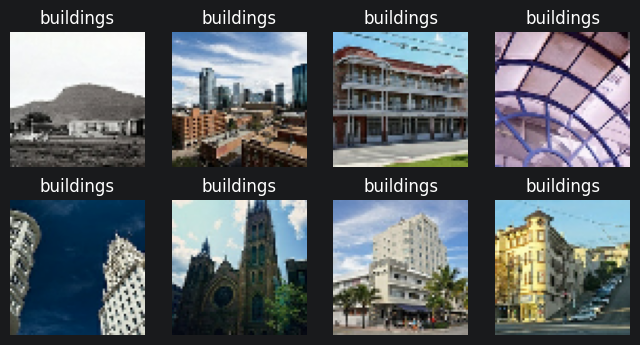

In [9]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 2000 images, except for street, which only has 150 images.
This should lead to a worse performance of this class.

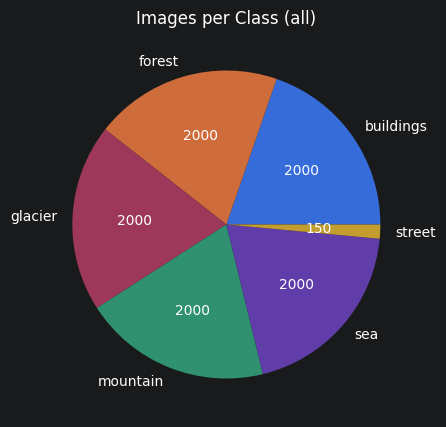

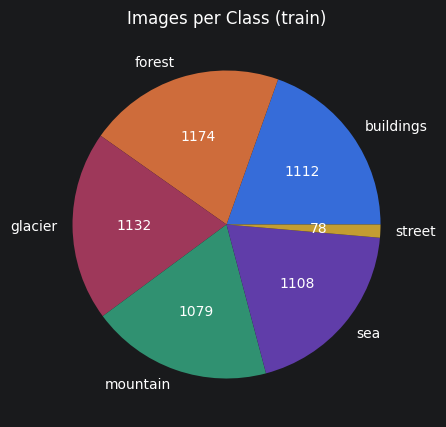

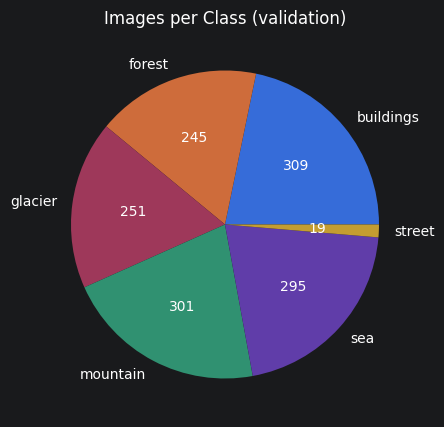

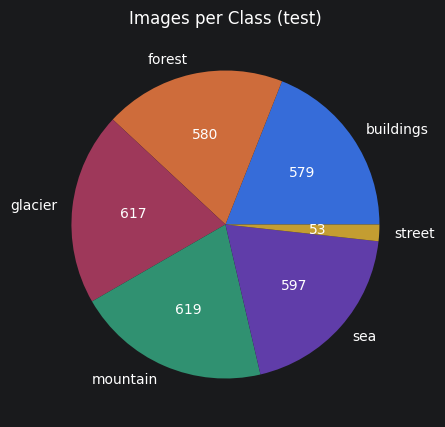

In [10]:
plot_number_per_class("Images per Class (all)", all_images, label_names)
plot_number_per_class("Images per Class (train)", train_images, label_names)
plot_number_per_class("Images per Class (validation)", validation_images, label_names)
plot_number_per_class("Images per Class (test)", test_images, label_names)

# Building the model

To obtain an underfitting model, the network is intentionally kept small by using only two convolutional layers followed by one dense layer for mapping to the classes.

The two convolutional layers are responsible for extracting features from the input images. The first layer learns basic visual patterns such as edges and textures, while the second layer extracts slightly more abstract features.
After each convolutional layer, a MaxPooling operation is applied to reduce the spatial size of the feature maps while preserving the most dominant information efectivly comprassing the image. This reduces the trainable parameters an so the models complexity.
The first MaxPooling layer reduces the image size moderately to retain sufficient information for further feature extraction. In contrast, the second MaxPooling layer performs a much stronger reduction, keeping only the most prominent features. After flattening, these compressed features are passed to the dense layer, which performs the final multi-class classification.

Because the model contains very few trainable parameters, it lacks the capacity to learn complex patterns sticking only to basic features, which should results in underfitting.

Why avoid stride>kernel-size: Strides larger than the kernel size should be avoided otherwise parts of the image would be skip, causing information loss during feature extraction. Espacali when having sharp edges (sky to building) skipping over pixels could be bad.

In [11]:
model = models.Sequential([
    layers.Input(shape=image_size +(3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(8, (3, 3), activation="relu"),
    layers.MaxPooling2D((8,8)),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           438 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,046 (7.99 KB)

 Trainable params: 2,046 (7.99 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4242 - loss: 1.4162 - val_accuracy: 0.5275 - val_loss: 1.1784
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5650 - loss: 1.0917 - val_accuracy: 0.5732 - val_loss: 1.0693
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6041 - loss: 1.0074 - val_accuracy: 0.6127 - val_loss: 1.0084
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6373 - loss: 0.9425 - val_accuracy: 0.6401 - val_loss: 0.9562
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6616 - loss: 0.8935 - val_accuracy: 0.6655 - val_loss: 0.9171
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6771 - loss: 0.8619 - val_accuracy: 0.6754 - val_loss: 0.8913
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6852 - loss: 0.8391 - val_accuracy: 0.6782 - val_loss: 0.8759
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6905 - loss: 0.8218 - val_accura

# Evaluating the model

Using a few plots we can see, that the model is underfitting.
Note that the loss is on a log scale to be able to interpret the results better.

In [13]:
true, pred = calculate_predictions(model, validation_images.batch(batch_size))

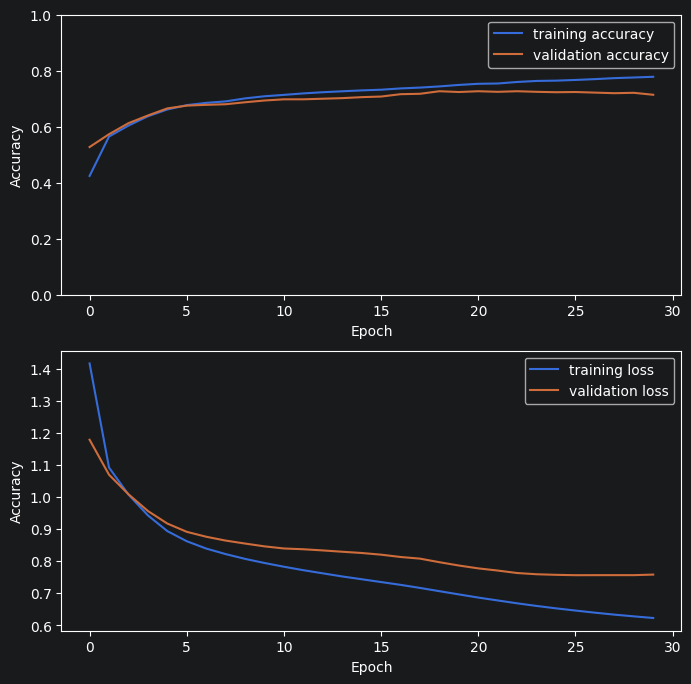

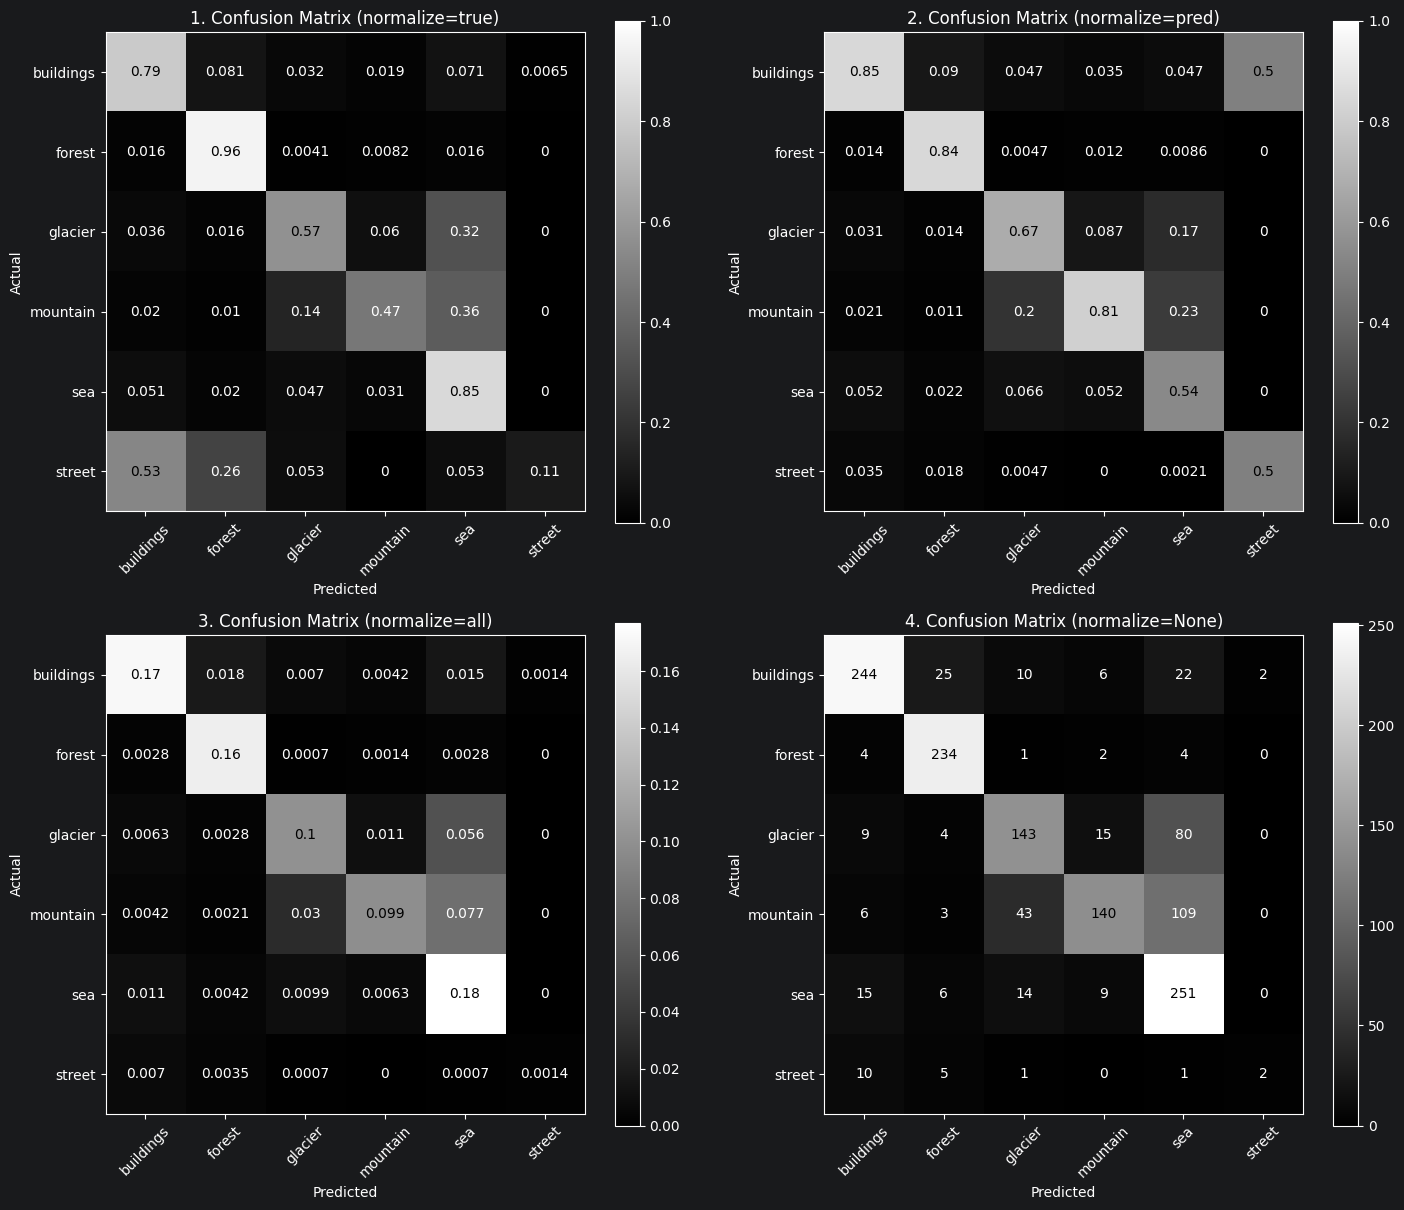

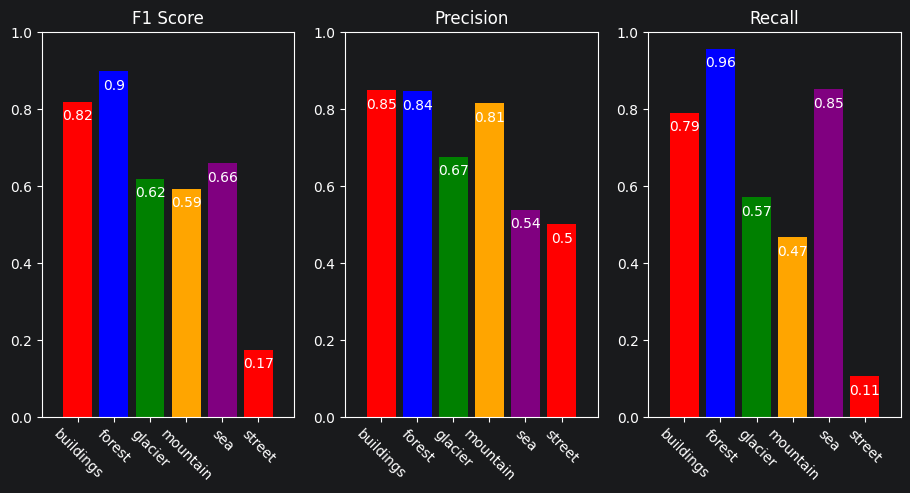

In [14]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"], log=False)

plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion

- The model has an accuracy of about 0.76.
- Accuracy: Here we can see two very typical things for underfitting models. Training accuracy and validation accuracy take almost the same path, so we have low variance. Also our model learsn a lot in the first vew epochs but then quickly stagnates.
- Loss: Tells us how well our model performs during training. We can see that our model is bad at predicting in the beginning but gets better very fast. Towards the end the validation loss is a bit higher then training loss which means that model performs worse on unseen data.
- Confusion Metrix:
  1. This is the recall matrix we can see the recall for each class combination. For example we can see that 66% of street samples got predicted as buildings by the model.
  2. This is the precision matrix. This tells us what happend when the model predicted a class. So the model predicted street and in 80% of cases it also was street but in 20% of cases it actuly was a building.
  3. This matrix shows wich classes dominated the models performance. So we can see that 18% of all samples were correctly classified as forest. This is quit usefully. If we look at the training metrix below we see that glacier did not performe so good. But looking at the matrix we see that 15% of all images were correctly classified as glaciers (glacier makes up about 20% of the samples).
  4. This is the same as 3 but the matrix does not add up to 1 insted it adds up to the number of samples in the dataset. This is great for seeing imbalances in the dataset. We can see that there are very vew street samples.
- Training metrics
    - F1 score: This tells us how balanced our model is, wich is not very balanced there are very little street samples. This is not surprising because we only have 150 street samples.
    - Precision: Precision measures how many of the samples predicted as a given class are actually of that class. And here somthing surprising happens. The street class with only 150 samples seams to get predicted better then most other classes. But this is misleading and explained by the recall.
    - Recall: The recall tells us that only a tiny amount of streets even get classified as such. So the model only predicts street if it is really confident, which explains the high precision. The recall also nicely shows the high bias of an underfitting model, by only seldon predicting street.

From both confusion matrix and training metrics we see that given the simplicety of the model it still learned the forest class quite well. This is probably due to forest beeing very different to all other classes.

